<a href="https://colab.research.google.com/github/Sanjayram3269/FUTURE_ML_01/blob/main/sales_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install prophet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error


In [ ]:
!pip install prophet --quiet

import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [ ]:
url = "https://raw.githubusercontent.com/Sanjayram3269/FUTURE_ML_01/refs/heads/main/Task1_Sales_Forecasting/Task1_Sales_Forecasting/data/train.csv"

df = pd.read_csv(url)
df['Date'] = pd.to_datetime(df['Date'])

df.head()


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [ ]:
prophet_df = df[['Date','Weekly_Sales']].rename(columns={
    'Date': 'ds',
    'Weekly_Sales': 'y'
})
prophet_df.head()


,ds,y
0,2010-02-05,24924.50
1,2010-02-12,46039.49
2,2010-02-19,41595.55
3,2010-02-26,19403.54
4,2010-03-05,21827.90


In [ ]:
train = prophet_df[:-10]
test = prophet_df[-10:]


In [ ]:
model = Prophet()
model.fit(train)


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = model.make_future_dataframe(periods=10, freq='W')
forecast = model.predict(future)
forecast.tail()


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
148,2012-12-02,16282.737274,-8689.061518,48942.173942,16274.192164,16291.093398,2699.163600,2699.163600,2699.163600,2699.163600,2699.163600,2699.163600,0.0,0.0,0.0,18981.900874
149,2012-12-09,16285.486708,-8792.884080,48788.416857,16274.276431,16296.997907,4146.379761,4146.379761,4146.379761,4146.379761,4146.379761,4146.379761,0.0,0.0,0.0,20431.866469
150,2012-12-16,16288.236143,-8270.046811,50066.667447,16273.894945,16302.893315,5353.971633,5353.971633,5353.971633,5353.971633,5353.971633,5353.971633,0.0,0.0,0.0,21642.207775
151,2012-12-23,16290.985577,-7810.847603,48824.425007,16273.628880,16308.757557,4973.142232,4973.142232,4973.142232,4973.142232,4973.142232,4973.142232,0.0,0.0,0.0,21264.127809
152,2012-12-30,16293.735012,-9971.420538,46680.632888,16273.576993,16314.418217,2547.352278,2547.352278,2547.352278,2547.352278,2547.352278,2547.352278,0.0,0.0,0.0,18841.087290


In [ ]:
forecast_output = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
forecast_output.to_csv("forecast_output.csv", index=False)

forecast_output


,ds,yhat,yhat_lower,yhat_upper
0,2010-02-05,16374.847308,-11333.654681,47275.964644
1,2010-02-12,16560.528304,-13024.222039,44336.670307
2,2010-02-19,16083.630074,-11883.715454,42706.692638
3,2010-02-26,15697.183589,-10261.830398,43718.775614
4,2010-03-05,15641.229945,-14127.579785,44534.425279
...,...,...,...,...
148,2012-12-02,18981.900874,-8689.061518,48942.173942
149,2012-12-09,20431.866469,-8792.884080,48788.416857
150,2012-12-16,21642.207775,-8270.046811,50066.667447
151,2012-12-23,21264.127809,-7810.847603,48824.425007


In [ ]:
actual_vs_forecast = test.merge(
    forecast_output,
    on='ds',
    how='left'
)

actual_vs_forecast.to_csv("actual_vs_forecast.csv", index=False)
actual_vs_forecast


,ds,y,yhat,yhat_lower,yhat_upper
0,2012-08-24,415.40,16370.235423,-13848.567552,45476.019114
1,2012-08-31,346.04,16294.927315,-11224.179356,43471.191831
2,2012-09-07,352.44,15745.644809,-13322.379084,46241.069376
3,2012-09-14,605.96,15028.451619,-11771.382830,43008.099328
4,2012-09-21,467.30,14701.805696,-11218.972500,44348.354692
5,2012-09-28,508.37,14972.511491,-14627.380820,43260.570668
6,2012-10-05,628.10,15437.758117,-12608.865403,44815.714432
7,2012-10-12,1061.02,15550.901928,-13449.978442,42300.578179
8,2012-10-19,760.01,15291.973144,-11684.614148,45629.020076
9,2012-10-26,1076.80,15211.034089,-15278.567878,40929.862380


In [ ]:
mae = mean_absolute_error(actual_vs_forecast['y'], actual_vs_forecast['yhat'])
rmse = np.sqrt(mean_squared_error(actual_vs_forecast['y'], actual_vs_forecast['yhat']))

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 14838.380363009535
RMSE: 14852.449354022627


In [ ]:
holiday_summary = df.groupby('IsHoliday')['Weekly_Sales'].mean().reset_index()
holiday_summary.rename(columns={'Weekly_Sales': 'Avg_Weekly_Sales'}, inplace=True)

holiday_summary.to_csv("holiday_sales_summary.csv", index=False)
holiday_summary


,IsHoliday,Avg_Weekly_Sales
0,False,15901.445069
1,True,17035.823187


In [ ]:
from google.colab import files
files.download("forecast_output.csv")
files.download("actual_vs_forecast.csv")
files.download("holiday_sales_summary.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from prophet.plot import plot_components_plotly
plot_components_plotly(model, forecast)


/usr/local/lib/python3.12/dist-packages/plotly/io/_json.py:560: UserWarning:

Discarding nonzero nanoseconds in conversion.



In [ ]:
from prophet.plot import plot_plot
import matplotlib.pyplot as plt

fig = plot_plot(model, forecast)
plt.title("Prophet Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()


ImportError: cannot import name 'plot_plot' from 'prophet.plot' (/usr/local/lib/python3.12/dist-packages/prophet/plot.py)

In [ ]:
from prophet.plot import plot
import matplotlib.pyplot as plt

fig = plot(model=model, fcst=forecast)
plt.title("Prophet Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()


TypeError: plot() got an unexpected keyword argument 'model'

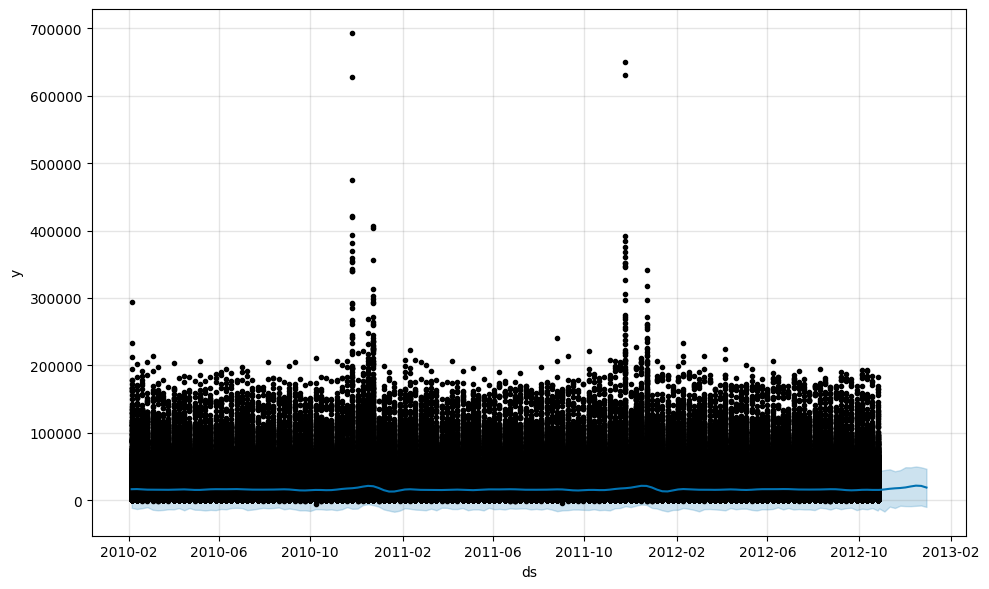

In [ ]:
from prophet.plot import plot
import matplotlib.pyplot as plt

fig = plot(model, forecast)
plt.tight_layout()
plt.show()


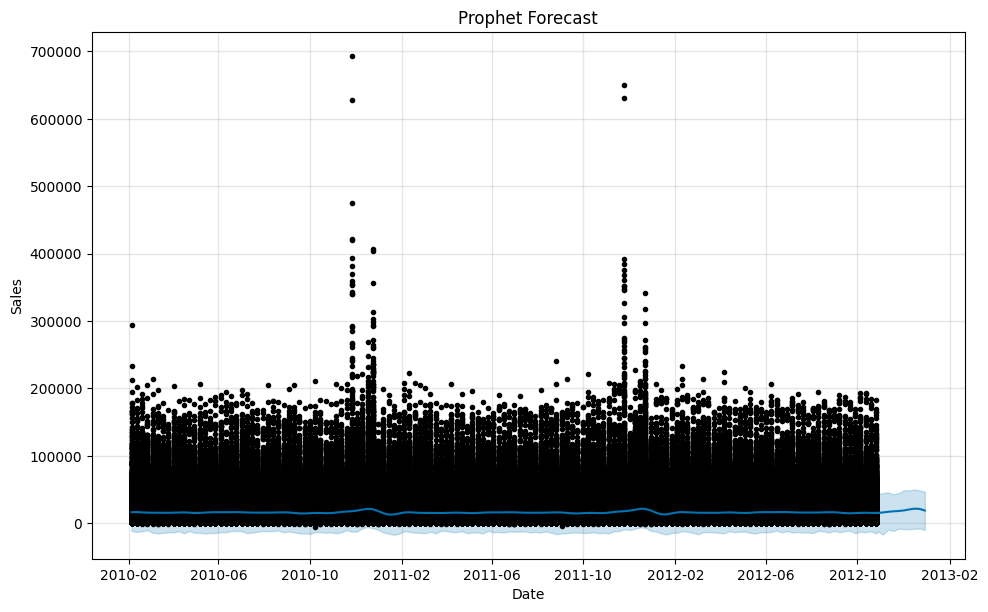

In [ ]:
import matplotlib.pyplot as plt

fig = model.plot(forecast)
plt.title("Prophet Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()
